# Compiling final results

In [ ]:
from pathlib import Path
import os

PROJECT_ROOT = Path.cwd()
SERVER_DIR = PROJECT_ROOT / "../server_trained_models"

paths = {
    "server_dir": SERVER_DIR,
    "configs": SERVER_DIR / "configs",
    "logs": SERVER_DIR / "logs",
    "optuna_studies": SERVER_DIR / "optuna_studies",
    "trained_models": SERVER_DIR / "trained_models",
}

print("Project root:", PROJECT_ROOT)
print("\nArtifact folders:")
for name, path in paths.items():
    print(f"  {name:15s} exists={path.exists()} path={path}")

print("\nTrained models:")
for p in sorted((SERVER_DIR / "trained_models").glob("*.zip")):
    size_mb = p.stat().st_size / (1024**2)
    print(f"  {p.name:80s} {size_mb:8.1f} MB")

print("\nTensorBoard log runs:")
for run_dir in sorted((SERVER_DIR / "logs").iterdir()):
    if run_dir.is_dir():
        event_files = list(run_dir.glob("events.out.tfevents.*"))
        if event_files:
            total_kb = sum(f.stat().st_size for f in event_files) / 1024
            print(
                f"  {run_dir.name:90s} files={len(event_files):2d} size={total_kb:8.1f} KB"
            )

print("\nOptuna study data64s:")
for p in sorted((SERVER_DIR / "optuna_studies").glob("*.db")):
    size_kb = p.stat().st_size / 1024
    print(f"  {p.name:70s} {size_kb:8.1f} KB")

print("\nReadability check:")
test_files = [
    SERVER_DIR / "configs" / "experiments" / "server_ppo_lstm.yaml",
    SERVER_DIR / "configs" / "experiments" / "server_ppo_resnet18_lstm_ft.yaml",
    SERVER_DIR / "logs" / "server_lstm_ppo_img224_5M_1",
    SERVER_DIR / "optuna_studies" / "optuna_server_ppo_lstm_64line_img224.db",
]

for p in test_files:
    try:
        if p.is_dir():
            event_file = next(p.glob("events.out.tfevents.*"))
            with open(event_file, "rb") as f:
                f.read(16)
            print(f"  OK   {event_file}")
        else:
            with open(p, "rb") as f:
                f.read(16)
            print(f"  OK   {p}")
    except Exception as e:
        print(f"  FAIL {p} -> {type(e).__name__}: {e}")

print("\nTensorBoard scalar tags for final 5M runs:")
try:
    from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

    final_runs = [
        SERVER_DIR / "logs" / "server_lstm_ppo_img224_5M_1",
        SERVER_DIR / "logs" / "server_resnet18_lstm_ft_img224_5M_1",
    ]

    for run_dir in final_runs:
        print(f"\n{run_dir.name}")
        ea = EventAccumulator(str(run_dir))
        ea.Reload()
        for tag in ea.Tags().get("scalars", []):
            events = ea.Scalars(tag)
            print(
                f"  {tag:35s} points={len(events):4d} first_step={events[0].step if events else None} last_step={events[-1].step if events else None}"
            )

except Exception as e:
    print("Could not read TensorBoard logs:", type(e).__name__, e)

Project root: c:\Users\prajapaa\OneDrive - The University of Colorado Denver\PHD\Courses\CSCI_5931_DL\project\DeepLearningWorldModelProject\notebooks

Artifact folders:
  server_dir      exists=True path=c:\Users\prajapaa\OneDrive - The University of Colorado Denver\PHD\Courses\CSCI_5931_DL\project\DeepLearningWorldModelProject\notebooks\..\server_trained_models
  configs         exists=True path=c:\Users\prajapaa\OneDrive - The University of Colorado Denver\PHD\Courses\CSCI_5931_DL\project\DeepLearningWorldModelProject\notebooks\..\server_trained_models\configs
  logs            exists=True path=c:\Users\prajapaa\OneDrive - The University of Colorado Denver\PHD\Courses\CSCI_5931_DL\project\DeepLearningWorldModelProject\notebooks\..\server_trained_models\logs
  optuna_studies  exists=True path=c:\Users\prajapaa\OneDrive - The University of Colorado Denver\PHD\Courses\CSCI_5931_DL\project\DeepLearningWorldModelProject\notebooks\..\server_trained_models\optuna_studies
  trained_models  e

In [5]:
from pathlib import Path
import pandas as pd
import numpy as np
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

# Notebook is inside notebooks/, so project root is one level up.
PROJECT_ROOT = Path.cwd().parent
SERVER_DIR = PROJECT_ROOT / "server_trained_models"
LOG_DIR = SERVER_DIR / "logs"

# Runs we care about for the current story.
# "64" means the earlier/default image-size run. We will verify exact image size from configs later if needed.
RUNS = {
    "PPO-LSTM, 64 image, 1M": {
        "model": "PPO-LSTM",
        "image_size": "64",
        "timesteps": "1M",
        "run_dir": LOG_DIR / "server_lstm_ppo_2",
    },
    "PPO-LSTM, 128 image, 1M": {
        "model": "PPO-LSTM",
        "image_size": "128",
        "timesteps": "1M",
        "run_dir": LOG_DIR / "server_lstm_ppo_img128_1",
    },
    "PPO-LSTM, 224 image, 1M": {
        "model": "PPO-LSTM",
        "image_size": "224",
        "timesteps": "1M",
        "run_dir": LOG_DIR / "server_lstm_ppo_img224_1",
    },
    "PPO-LSTM, 224 image, 5M": {
        "model": "PPO-LSTM",
        "image_size": "224",
        "timesteps": "5M",
        "run_dir": LOG_DIR / "server_lstm_ppo_img224_5M_1",
    },
    "PPO-ResNet18-LSTM-FT, 64 image, 1M": {
        "model": "PPO-ResNet18-LSTM-FT",
        "image_size": "64",
        "timesteps": "1M",
        "run_dir": LOG_DIR / "server_resnet18_lstm_ft_2",
    },
    "PPO-ResNet18-LSTM-FT, 128 image, 1M": {
        "model": "PPO-ResNet18-LSTM-FT",
        "image_size": "128",
        "timesteps": "1M",
        "run_dir": LOG_DIR / "server_resnet18_lstm_ft_img128_1",
    },
    "PPO-ResNet18-LSTM-FT, 224 image, 1M": {
        "model": "PPO-ResNet18-LSTM-FT",
        "image_size": "224",
        "timesteps": "1M",
        "run_dir": LOG_DIR / "server_resnet18_lstm_ft_img224_1",
    },
    "PPO-ResNet18-LSTM-FT, 224 image, 5M": {
        "model": "PPO-ResNet18-LSTM-FT",
        "image_size": "224",
        "timesteps": "5M",
        "run_dir": LOG_DIR / "server_resnet18_lstm_ft_img224_5M_1",
    },
}


def read_tb_scalar(run_dir: Path, tag: str = "rollout/ep_rew_mean") -> pd.DataFrame:
    """Read one scalar tag from a TensorBoard run directory."""
    ea = EventAccumulator(str(run_dir))
    ea.Reload()

    available = ea.Tags().get("scalars", [])
    if tag not in available:
        raise KeyError(
            f"{tag} not found in {run_dir.name}. Available tags: {available}"
        )

    events = ea.Scalars(tag)
    return pd.DataFrame(
        {
            "step": [e.step for e in events],
            "value": [e.value for e in events],
            "wall_time": [e.wall_time for e in events],
        }
    )


curves = []

for label, meta in RUNS.items():
    df = read_tb_scalar(meta["run_dir"], "rollout/ep_rew_mean")
    df["run_label"] = label
    df["model"] = meta["model"]
    df["image_size"] = meta["image_size"]
    df["timesteps"] = meta["timesteps"]
    df["run_dir"] = meta["run_dir"].name
    curves.append(df)

curves_df = pd.concat(curves, ignore_index=True)

summary_df = (
    curves_df.groupby(["model", "image_size", "timesteps", "run_dir"], as_index=False)
    .agg(
        points=("value", "size"),
        first_step=("step", "min"),
        last_step=("step", "max"),
        first_reward=("value", "first"),
        final_reward=("value", "last"),
        max_reward=("value", "max"),
    )
    .sort_values(["model", "image_size", "timesteps"])
)

display(summary_df)

,model,image_size,timesteps,run_dir,points,first_step,last_step,first_reward,final_reward,max_reward
0,PPO-LSTM,128,1M,server_lstm_ppo_img128_1,40,25600,1024000,16.072985,170.037094,170.037094
1,PPO-LSTM,224,1M,server_lstm_ppo_img224_1,40,25600,1024000,15.217141,66.243530,70.967560
2,PPO-LSTM,224,5M,server_lstm_ppo_img224_5M_1,196,25600,5017600,12.501879,344.048676,344.048676
3,PPO-LSTM,64,1M,server_lstm_ppo_2,40,25600,1024000,16.933975,167.969513,167.969513
4,PPO-ResNet18-LSTM-FT,128,1M,server_resnet18_lstm_ft_img128_1,40,25600,1024000,15.729678,28.865271,44.787106
5,PPO-ResNet18-LSTM-FT,224,1M,server_resnet18_lstm_ft_img224_1,40,25600,1024000,14.761731,156.188354,156.188354
6,PPO-ResNet18-LSTM-FT,224,5M,server_resnet18_lstm_ft_img224_5M_1,196,25600,5017600,15.744036,359.583801,394.165161
7,PPO-ResNet18-LSTM-FT,64,1M,server_resnet18_lstm_ft_2,40,25600,1024000,15.825503,18.914398,40.642258


Saved: c:\Users\prajapaa\OneDrive - The University of Colorado Denver\PHD\Courses\CSCI_5931_DL\project\DeepLearningWorldModelProject\results\figures\image_size_training_comparison.svg
Saved: c:\Users\prajapaa\OneDrive - The University of Colorado Denver\PHD\Courses\CSCI_5931_DL\project\DeepLearningWorldModelProject\results\figures\image_size_training_comparison.pdf


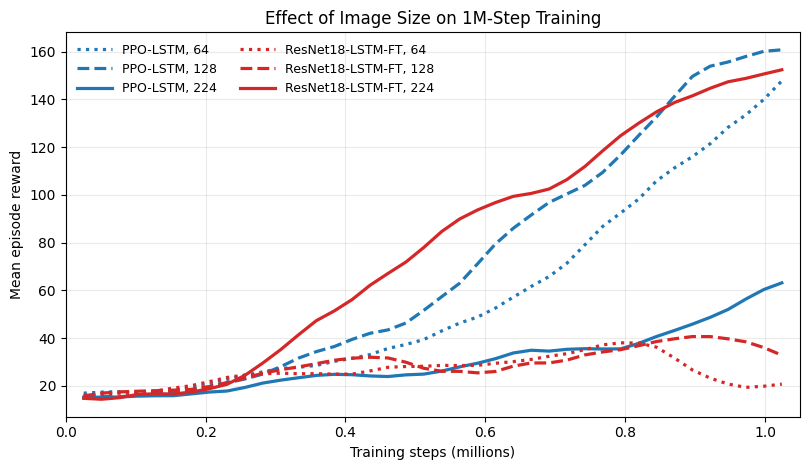

In [ ]:
import matplotlib.pyplot as plt


def smooth_series(values, window=5):
    return pd.Series(values).rolling(window=window, min_periods=1).mean().to_numpy()


plot_df = curves_df[
    (curves_df["timesteps"] == "1M")
    & (curves_df["image_size"].isin(["64", "128", "224"]))
].copy()

model_order = ["PPO-LSTM", "PPO-ResNet18-LSTM-FT"]
image_size_order = ["64", "128", "224"]

color_map = {
    "PPO-LSTM": "#1f77b4",
    "PPO-ResNet18-LSTM-FT": "#d62728",
}

linestyle_map = {
    "64": ":",
    "128": "--",
    "224": "-",
}

label_map = {
    "PPO-LSTM": "PPO-LSTM",
    "PPO-ResNet18-LSTM-FT": "ResNet18-LSTM-FT",
}

fig, ax = plt.subplots(figsize=(8.2, 4.8))

handles = []
labels = []

for model in model_order:
    for image_size in image_size_order:
        group = plot_df[
            (plot_df["model"] == model) & (plot_df["image_size"] == image_size)
        ].sort_values("step")

        if group.empty:
            continue

        y = smooth_series(group["value"], window=5)

        (line,) = ax.plot(
            group["step"] / 1e6,
            y,
            color=color_map[model],
            linestyle=linestyle_map[image_size],
            linewidth=2.3,
        )

        handles.append(line)
        labels.append(f"{label_map[model]}, {image_size}")

ax.set_title("Effect of Image Size on 1M-Step Training")
ax.set_xlabel("Training steps (millions)")
ax.set_ylabel("Mean episode reward")
ax.grid(True, alpha=0.25)

ax.legend(
    handles,
    labels,
    frameon=False,
    fontsize=9,
    ncol=2,
    columnspacing=1.8,
    handlelength=2.8,
)

ax.set_xlim(0, 1.05)

plt.tight_layout()

out_path = PROJECT_ROOT / "results" / "figures" / "image_size_training_comparison.svg"
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_path, format="svg", bbox_inches="tight")
print(f"Saved: {out_path}")

out_path = PROJECT_ROOT / "results" / "figures" / "image_size_training_comparison.pdf"
fig.savefig(out_path, format="pdf", bbox_inches="tight")
print(f"Saved: {out_path}")

plt.show()

Saved: c:\Users\prajapaa\OneDrive - The University of Colorado Denver\PHD\Courses\CSCI_5931_DL\project\DeepLearningWorldModelProject\results\figures\training_length_224_comparison.svg
Saved: c:\Users\prajapaa\OneDrive - The University of Colorado Denver\PHD\Courses\CSCI_5931_DL\project\DeepLearningWorldModelProject\results\figures\training_length_224_comparison.pdf


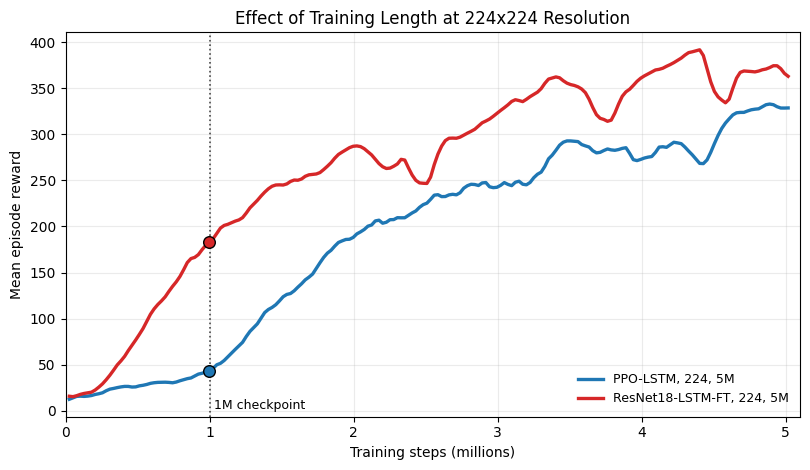

In [ ]:
plot_df = curves_df[
    (curves_df["image_size"] == "224") & (curves_df["timesteps"] == "5M")
].copy()

fig, ax = plt.subplots(figsize=(8.2, 4.8))

styles = {
    "PPO-LSTM": {
        "color": "#1f77b4",
        "label": "PPO-LSTM, 224, 5M",
        "linewidth": 2.4,
    },
    "PPO-ResNet18-LSTM-FT": {
        "color": "#d62728",
        "label": "ResNet18-LSTM-FT, 224, 5M",
        "linewidth": 2.4,
    },
}

for model, group in plot_df.groupby("model"):
    group = group.sort_values("step")
    y = smooth_series(group["value"], window=7)
    style = styles[model]

    ax.plot(
        group["step"] / 1e6,
        y,
        color=style["color"],
        linestyle="-",
        linewidth=style["linewidth"],
        label=style["label"],
    )

    # Mark reward near the 1M checkpoint on the 5M curve
    idx_1m = (group["step"] - 1_000_000).abs().idxmin()
    step_1m = group.loc[idx_1m, "step"] / 1e6
    reward_1m = y[group.index.get_loc(idx_1m)]

    ax.scatter(
        step_1m,
        reward_1m,
        color=style["color"],
        edgecolor="black",
        s=70,
        zorder=5,
    )

ax.axvline(1.0, color="black", linestyle=":", linewidth=1.2, alpha=0.7)
ax.text(1.03, ax.get_ylim()[0] + 8, "1M checkpoint", fontsize=9, color="black")

ax.set_title("Effect of Training Length at 224x224 Resolution")
ax.set_xlabel("Training steps (millions)")
ax.set_ylabel("Mean episode reward")
ax.grid(True, alpha=0.25)
ax.legend(frameon=False, fontsize=9)
ax.set_xlim(0, 5.1)

plt.tight_layout()

out_path = PROJECT_ROOT / "results" / "figures" / "training_length_224_comparison.svg"
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_path, format="svg", bbox_inches="tight")
print(f"Saved: {out_path}")

out_path = PROJECT_ROOT / "results" / "figures" / "training_length_224_comparison.pdf"
fig.savefig(out_path, format="pdf", bbox_inches="tight")
print(f"Saved: {out_path}")

plt.show()

In [ ]:
import sqlite3
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
OPTUNA_DIR = PROJECT_ROOT / "server_trained_models" / "optuna_studies"

db_files = sorted(OPTUNA_DIR.glob("*.db"))
print("Optuna DB files:")
for db in db_files:
    print(" ", db.name)


def inspect_optuna_db(db_path: Path):
    con = sqlite3.connect(db_path)

    studies = pd.read_sql_query(
        """
        SELECT study_id, study_name
        FROM studies
        ORDER BY study_id
        """,
        con,
    )

    trials = pd.read_sql_query(
        """
        SELECT trial_id, number, state, datetime_start, datetime_complete
        FROM trials
        ORDER BY number
        """,
        con,
    )

    values = pd.read_sql_query(
        """
        SELECT trial_id, objective, value
        FROM trial_values
        ORDER BY trial_id, objective
        """,
        con,
    )

    params = pd.read_sql_query(
        """
        SELECT trial_id, param_name, param_value
        FROM trial_params
        ORDER BY trial_id, param_name
        """,
        con,
    )

    attrs = pd.read_sql_query(
        """
        SELECT trial_id, key, value_json
        FROM trial_user_attributes
        ORDER BY trial_id, key
        """,
        con,
    )

    con.close()

    return studies, trials, values, params, attrs


for db in db_files:
    print("\n" + "=" * 100)
    print(db.name)

    studies, trials, values, params, attrs = inspect_optuna_db(db)

    print("\nStudies:")
    display(studies)

    print("Trials:")
    display(trials)

    print("Values:")
    display(values.head(20))

    print("Params:")
    display(params.head(30))

    print("User attributes:")
    display(attrs.head(30))

Optuna DB files:
  optuna_server_ppo_lstm_baseline.db
  optuna_server_ppo_lstm_baseline_img224.db
  optuna_server_ppo_resnet18_lstm_ft_baseline.db
  optuna_server_ppo_resnet18_lstm_ft_baseline_img224.db
  ppo_baseline.db

optuna_server_ppo_lstm_baseline.db

Studies:


,study_id,study_name
0,1,optuna_server_ppo_lstm_baseline


Trials:


,trial_id,number,state,datetime_start,datetime_complete
0,1,0,FAIL,2026-05-09 18:11:34.531169,2026-05-09 18:11:36.240589
1,2,1,COMPLETE,2026-05-09 18:11:57.950937,2026-05-09 18:47:21.520287
2,3,2,COMPLETE,2026-05-09 18:47:21.530576,2026-05-09 19:20:52.673835
3,4,3,FAIL,2026-05-09 19:20:52.683426,2026-05-09 19:52:26.756117
4,5,4,FAIL,2026-05-09 21:58:06.703746,2026-05-09 21:59:41.951570


Values:


...

,trial_id,objective,value


Params:


,trial_id,param_name,param_value


User attributes:


,trial_id,key,value_json


c:\Users\prajapaa\AppData\Local\anaconda3\envs\worldmodel\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,model,trial,mean_reward,mean_distance,success_rate,mean_fluidity,learning_rate,n_steps,lstm_hidden_size,unfreeze_layers
0,"PPO-LSTM, 224",6,174.046795,0.184163,0.0,339.297605,0.00010,512,128,
1,"PPO-LSTM, 224",9,12.442547,0.723869,0.0,179.597527,0.00100,512,256,
2,"PPO-LSTM, 224",2,12.177971,0.740436,0.0,22837.531249,0.00100,512,256,
3,"PPO-LSTM, 224",1,10.365589,0.510224,0.0,34.805018,0.00001,512,128,
4,"PPO-LSTM, 224",4,9.139973,0.555773,0.0,28.292927,0.00001,512,256,
5,"PPO-LSTM, 224",5,7.095827,0.836676,0.0,254.010758,0.00100,512,256,
6,"PPO-LSTM, 224",8,6.191837,0.899028,0.0,326.382083,0.00100,512,128,
7,"PPO-LSTM, 224",0,6.176354,0.935899,0.0,327.231072,0.00100,512,128,
8,"PPO-LSTM, 224",7,3.441801,0.924859,0.0,188.833127,0.00100,512,128,
9,"ResNet18-LSTM-FT, 224",5,41.315396,0.181319,0.0,628.029702,0.00100,512,128,layer4


Saved: c:\Users\prajapaa\OneDrive - The University of Colorado Denver\PHD\Courses\CSCI_5931_DL\project\DeepLearningWorldModelProject\results\figures\focused_optuna_tuning.svg


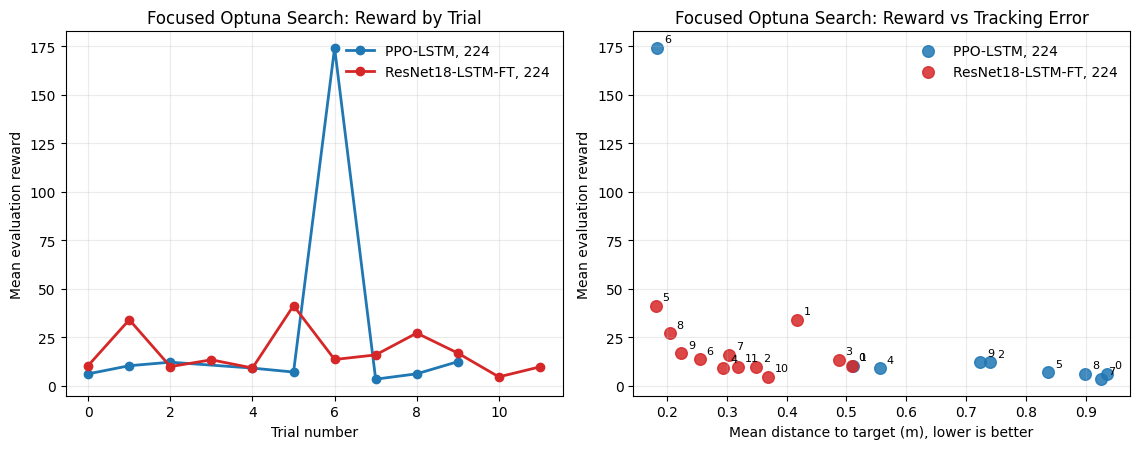

In [ ]:
import optuna
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
OPTUNA_DIR = PROJECT_ROOT / "server_trained_models" / "optuna_studies"

FOCUSED_STUDIES = {
    "PPO-LSTM, 224": {
        "db": OPTUNA_DIR / "optuna_server_ppo_lstm_baseline_img224.db",
        "study_name": "optuna_server_ppo_lstm_baseline_img224",
    },
    "ResNet18-LSTM-FT, 224": {
        "db": OPTUNA_DIR / "optuna_server_ppo_resnet18_lstm_ft_baseline_img224.db",
        "study_name": "optuna_server_ppo_resnet18_lstm_ft_baseline_img224",
    },
}

rows = []

for label, cfg in FOCUSED_STUDIES.items():
    study = optuna.load_study(
        study_name=cfg["study_name"],
        storage=f"sqlite:///{cfg['db']}",
    )

    for t in study.trials:
        if t.state.name != "COMPLETE":
            continue

        rows.append(
            {
                "model": label,
                "trial": t.number,
                "mean_reward": t.user_attrs.get("mean_reward"),
                "mean_distance": t.user_attrs.get("mean_distance"),
                "success_rate": t.user_attrs.get("success_rate"),
                "mean_fluidity": t.user_attrs.get("mean_fluidity"),
                "learning_rate": t.params.get("learning_rate"),
                "n_steps": t.params.get("n_steps"),
                "lstm_hidden_size": t.params.get("lstm_hidden_size"),
                "unfreeze_layers": str(t.params.get("unfreeze_layers", "")),
            }
        )

focused_optuna_df = pd.DataFrame(rows)

display(
    focused_optuna_df.sort_values(
        ["model", "mean_reward"], ascending=[True, False]
    ).reset_index(drop=True)
)

colors = {
    "PPO-LSTM, 224": "#1f77b4",
    "ResNet18-LSTM-FT, 224": "#d62728",
}

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))

# Panel 1: reward by trial
for model, group in focused_optuna_df.groupby("model"):
    group = group.sort_values("trial")
    axes[0].plot(
        group["trial"],
        group["mean_reward"],
        marker="o",
        linewidth=2,
        color=colors[model],
        label=model,
    )

axes[0].set_title("Focused Optuna Search: Reward by Trial")
axes[0].set_xlabel("Trial number")
axes[0].set_ylabel("Mean evaluation reward")
axes[0].grid(True, alpha=0.25)
axes[0].legend(frameon=False)

# Panel 2: reward vs distance
for model, group in focused_optuna_df.groupby("model"):
    axes[1].scatter(
        group["mean_distance"],
        group["mean_reward"],
        s=70,
        color=colors[model],
        label=model,
        alpha=0.85,
    )

    for _, row in group.iterrows():
        axes[1].annotate(
            str(int(row["trial"])),
            (row["mean_distance"], row["mean_reward"]),
            textcoords="offset points",
            xytext=(5, 4),
            fontsize=8,
        )

axes[1].set_title("Focused Optuna Search: Reward vs Tracking Error")
axes[1].set_xlabel("Mean distance to target (m), lower is better")
axes[1].set_ylabel("Mean evaluation reward")
axes[1].grid(True, alpha=0.25)
axes[1].legend(frameon=False)

plt.tight_layout()

out_path = PROJECT_ROOT / "results" / "figures" / "focused_optuna_tuning.svg"
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_path, format="svg", bbox_inches="tight")
print(f"Saved: {out_path}")

plt.show()

Saved: c:\Users\prajapaa\OneDrive - The University of Colorado Denver\PHD\Courses\CSCI_5931_DL\project\DeepLearningWorldModelProject\results\figures\focused_optuna_pareto_fronts.pdf


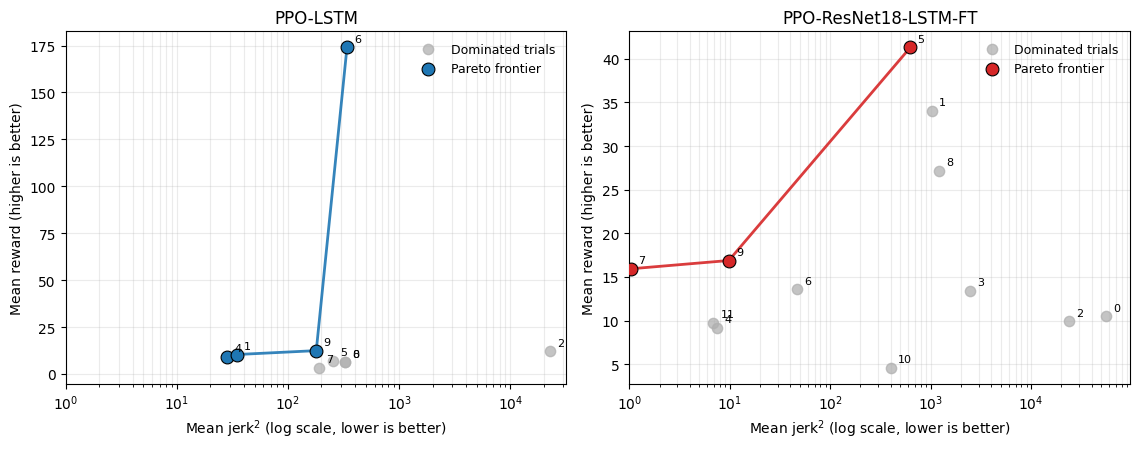

In [36]:
import optuna
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
OPTUNA_DIR = PROJECT_ROOT / "server_trained_models" / "optuna_studies"

STUDIES = {
    "PPO-LSTM": {
        "db": OPTUNA_DIR / "optuna_server_ppo_lstm_baseline_img224.db",
        "study_name": "optuna_server_ppo_lstm_baseline_img224",
        "color": "#1f77b4",
    },
    "PPO-ResNet18-LSTM-FT": {
        "db": OPTUNA_DIR / "optuna_server_ppo_resnet18_lstm_ft_baseline_img224.db",
        "study_name": "optuna_server_ppo_resnet18_lstm_ft_baseline_img224",
        "color": "#d62728",
    },
}


def is_pareto_efficient(df):
    """
    Pareto frontier for:
    - maximize mean_reward
    - minimize mean_fluidity
    """
    pareto = []

    for i, row in df.iterrows():
        dominated = False

        for j, other in df.iterrows():
            if i == j:
                continue

            better_or_equal_reward = other["mean_reward"] >= row["mean_reward"]
            better_or_equal_fluidity = other["mean_fluidity"] <= row["mean_fluidity"]
            strictly_better = (
                other["mean_reward"] > row["mean_reward"]
                or other["mean_fluidity"] < row["mean_fluidity"]
            )

            if better_or_equal_reward and better_or_equal_fluidity and strictly_better:
                dominated = True
                break

        pareto.append(not dominated)

    return pareto


rows = []

for model, cfg in STUDIES.items():
    study = optuna.load_study(
        study_name=cfg["study_name"],
        storage=f"sqlite:///{cfg['db']}",
    )

    for trial in study.trials:
        if trial.state.name != "COMPLETE":
            continue

        rows.append(
            {
                "model": model,
                "trial": trial.number,
                "mean_reward": trial.user_attrs.get("mean_reward"),
                "mean_fluidity": trial.user_attrs.get("mean_fluidity"),
                "learning_rate": trial.params.get("learning_rate"),
                "n_steps": trial.params.get("n_steps"),
                "lstm_hidden_size": trial.params.get("lstm_hidden_size"),
                "unfreeze_layers": trial.params.get("unfreeze_layers", ""),
            }
        )

pareto_df = pd.DataFrame(rows)
pareto_df["is_pareto"] = False

for model in pareto_df["model"].unique():
    idx = pareto_df["model"] == model
    pareto_df.loc[idx, "is_pareto"] = is_pareto_efficient(pareto_df[idx])

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6), sharey=False)

for ax, (model, cfg) in zip(axes, STUDIES.items()):
    df = pareto_df[pareto_df["model"] == model].copy()

    non_pareto = df[~df["is_pareto"]]
    pareto = df[df["is_pareto"]].sort_values("mean_fluidity")

    ax.scatter(
        non_pareto["mean_fluidity"],
        non_pareto["mean_reward"],
        s=55,
        color="#B0B0B0",
        alpha=0.75,
        label="Dominated trials",
    )

    ax.scatter(
        pareto["mean_fluidity"],
        pareto["mean_reward"],
        s=85,
        color=cfg["color"],
        edgecolor="black",
        linewidth=0.8,
        label="Pareto frontier",
        zorder=3,
    )

    ax.plot(
        pareto["mean_fluidity"],
        pareto["mean_reward"],
        color=cfg["color"],
        linewidth=2,
        alpha=0.9,
        zorder=2,
    )

    for _, row in df.iterrows():
        ax.annotate(
            str(int(row["trial"])),
            (row["mean_fluidity"], row["mean_reward"]),
            textcoords="offset points",
            xytext=(5, 4),
            fontsize=8,
        )

    ax.set_title(model)
    ax.set_xlabel("Mean jerk$^2$ (log scale, lower is better)")
    ax.set_ylabel("Mean reward (higher is better)")
    ax.set_xscale("log")
    ax.set_xlim(left=1)
    ax.grid(True, alpha=0.25, which="both")
    ax.legend(frameon=False, fontsize=9)


plt.tight_layout()

out_path = PROJECT_ROOT / "results" / "figures" / "focused_optuna_pareto_fronts.pdf"
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_path, format="pdf", bbox_inches="tight")
print(f"Saved: {out_path}")

plt.show()

In [ ]:
import numpy as np
import pandas as pd


def first_step_at_or_above(group, threshold):
    group = group.sort_values("step")
    hit = group[group["value"] >= threshold]
    if hit.empty:
        return np.nan
    return hit.iloc[0]["step"]


thresholds = [50, 100, 150, 250, 300]

summary_rows = []

for (model, image_size, timesteps, run_dir), group in curves_df.groupby(
    ["model", "image_size", "timesteps", "run_dir"]
):
    group = group.sort_values("step")

    row = {
        "model": model,
        "image_size": image_size,
        "timesteps": timesteps,
        "run_dir": run_dir,
        "final_step": int(group["step"].iloc[-1]),
        "final_reward": group["value"].iloc[-1],
        "max_reward": group["value"].max(),
    }

    for threshold in thresholds:
        step = first_step_at_or_above(group, threshold)
        row[f"steps_to_reward_{threshold}"] = step
        row[f"millions_to_reward_{threshold}"] = (
            step / 1e6 if not np.isnan(step) else np.nan
        )

    summary_rows.append(row)

results_summary_df = pd.DataFrame(summary_rows)

display(
    results_summary_df.sort_values(["model", "image_size", "timesteps"]).style.format(
        {
            "final_reward": "{:.2f}",
            "max_reward": "{:.2f}",
            "millions_to_reward_50": "{:.2f}",
            "millions_to_reward_100": "{:.2f}",
            "millions_to_reward_150": "{:.2f}",
            "millions_to_reward_250": "{:.2f}",
            "millions_to_reward_300": "{:.2f}",
        }
    )
)

# A smaller report-friendly version for the final 224x224 comparison
final_224_summary = results_summary_df[
    (results_summary_df["image_size"] == "224")
    & (results_summary_df["timesteps"] == "5M")
][
    [
        "model",
        "final_reward",
        "max_reward",
        "millions_to_reward_100",
        "millions_to_reward_150",
        "millions_to_reward_250",
        "millions_to_reward_300",
    ]
]

display(
    final_224_summary.sort_values("final_reward", ascending=False).style.format(
        {
            "final_reward": "{:.2f}",
            "max_reward": "{:.2f}",
            "millions_to_reward_100": "{:.2f}",
            "millions_to_reward_150": "{:.2f}",
            "millions_to_reward_250": "{:.2f}",
            "millions_to_reward_300": "{:.2f}",
        }
    )
)

,model,image_size,timesteps,run_dir,final_step,final_reward,max_reward,steps_to_reward_50,millions_to_reward_50,steps_to_reward_100,millions_to_reward_100,steps_to_reward_150,millions_to_reward_150,steps_to_reward_250,millions_to_reward_250,steps_to_reward_300,millions_to_reward_300
0,PPO-LSTM,128,1M,server_lstm_ppo_img128_1,1024000,170.04,170.04,486400.000000,0.49,665600.000000,0.67,870400.000000,0.87,nan,nan,nan,nan
1,PPO-LSTM,224,1M,server_lstm_ppo_img224_1,1024000,66.24,70.97,870400.000000,0.87,nan,nan,nan,nan,nan,nan,nan,nan
2,PPO-LSTM,224,5M,server_lstm_ppo_img224_5M_1,5017600,344.05,344.05,972800.000000,0.97,1280000.000000,1.28,1638400.000000,1.64,2739200.000000,2.74,3430400.000000,3.43
3,PPO-LSTM,64,1M,server_lstm_ppo_2,1024000,167.97,167.97,537600.000000,0.54,768000.000000,0.77,998400.000000,1.00,nan,nan,nan,nan
4,PPO-ResNet18-LSTM-FT,128,1M,server_resnet18_lstm_ft_img128_1,1024000,28.87,44.79,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
5,PPO-ResNet18-LSTM-FT,224,1M,server_resnet18_lstm_ft_img224_1,1024000,156.19,156.19,332800.000000,0.33,563200.000000,0.56,921600.000000,0.92,nan,nan,nan,nan
6,PPO-ResNet18-LSTM-FT,224,5M,server_resnet18_lstm_ft_img224_5M_1,5017600,359.58,394.17,281600.000000,0.28,512000.000000,0.51,742400.000000,0.74,1433600.000000,1.43,2739200.000000,2.74
7,PPO-ResNet18-LSTM-FT,64,1M,server_resnet18_lstm_ft_2,1024000,18.91,40.64,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan


,model,final_reward,max_reward,millions_to_reward_100,millions_to_reward_150,millions_to_reward_250,millions_to_reward_300
6,PPO-ResNet18-LSTM-FT,359.58,394.17,0.51,0.74,1.43,2.74
2,PPO-LSTM,344.05,344.05,1.28,1.64,2.74,3.43


In [29]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from stable_baselines3 import PPO
from sb3_contrib import RecurrentPPO

from utils.config import load_config
from sim.env import RoboticArmEnv
from evaluation.metrics import tracking_accuracy, fluidity

N_EPISODES = 100

EVAL_RUNS = {
    "PPO-LSTM": {
        "config": PROJECT_ROOT
        / "server_trained_models"
        / "configs"
        / "experiments"
        / "server_ppo_lstm.yaml",
        "model": PROJECT_ROOT
        / "server_trained_models"
        / "trained_models"
        / "server_ppo_lstm_img224_5M.zip",
    },
    "PPO-ResNet18-LSTM-FT": {
        "config": PROJECT_ROOT
        / "server_trained_models"
        / "configs"
        / "experiments"
        / "server_ppo_resnet18_lstm_ft.yaml",
        "model": PROJECT_ROOT
        / "server_trained_models"
        / "trained_models"
        / "server_ppo_resnet18_lstm_ft_imge224_5M.zip",
    },
}


def load_sb3_model(model_path, env):
    """Load PPO or RecurrentPPO, detecting recurrent models automatically."""
    try:
        model = RecurrentPPO.load(str(model_path), env=env)
        return model, True
    except Exception:
        model = PPO.load(str(model_path), env=env)
        return model, False


def evaluate_model_per_episode(label, config_path, model_path, n_episodes=100):
    config = load_config(str(config_path))
    env = RoboticArmEnv(config)
    model, is_recurrent = load_sb3_model(model_path, env)

    rows = []

    for ep in range(n_episodes):
        obs, _ = env.reset()

        done = False
        total_reward = 0.0
        distances = []
        joint_positions = []

        lstm_states = None
        episode_start = True
        final_info = {}

        while not done:
            if is_recurrent:
                action, lstm_states = model.predict(
                    obs,
                    state=lstm_states,
                    episode_start=episode_start,
                    deterministic=True,
                )
                episode_start = False
            else:
                action, _ = model.predict(obs, deterministic=True)

            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            total_reward += reward
            distances.append(info["eef_to_target"])
            joint_positions.append(info["joint_positions"])
            final_info = info

        joint_traj = np.stack(joint_positions)
        ep_fluidity = (
            fluidity(joint_traj, control_freq=20.0)
            if joint_traj.shape[0] > 3
            else np.nan
        )

        rows.append(
            {
                "model": label,
                "episode": ep + 1,
                "episode_return": float(total_reward),
                "tracking_distance": float(tracking_accuracy(distances)),
                "fluidity": float(ep_fluidity),
                "success": int(final_info.get("success", False)),
            }
        )

        print(
            f"{label:24s} | Episode {ep + 1:3d}/{n_episodes} | "
            f"return={total_reward:8.2f} | "
            f"dist={tracking_accuracy(distances):.4f} | "
            f"success={bool(final_info.get('success', False))}"
        )

    env.close()
    return rows


all_rows = []

for label, run in EVAL_RUNS.items():
    print("\n" + "=" * 100)
    print(f"Evaluating {label}")
    all_rows.extend(
        evaluate_model_per_episode(
            label=label,
            config_path=run["config"],
            model_path=run["model"],
            n_episodes=N_EPISODES,
        )
    )

eval_episode_df = pd.DataFrame(all_rows)

summary_df = eval_episode_df.groupby("model", as_index=False).agg(
    episodes=("episode", "count"),
    episode_return_mean=("episode_return", "mean"),
    episode_return_std=("episode_return", "std"),
    tracking_distance_mean=("tracking_distance", "mean"),
    tracking_distance_std=("tracking_distance", "std"),
    fluidity_mean=("fluidity", "mean"),
    fluidity_std=("fluidity", "std"),
    success_rate=("success", "mean"),
)

display(
    summary_df.style.format(
        {
            "episode_return_mean": "{:.3f}",
            "episode_return_std": "{:.3f}",
            "tracking_distance_mean": "{:.4f}",
            "tracking_distance_std": "{:.4f}",
            "fluidity_mean": "{:.3f}",
            "fluidity_std": "{:.3f}",
            "success_rate": "{:.1%}",
        }
    )
)

out_csv = PROJECT_ROOT / "results" / "final_5m_eval_per_episode.csv"
out_csv.parent.mkdir(parents=True, exist_ok=True)
eval_episode_df.to_csv(out_csv, index=False)
print(f"\nSaved per-episode evaluation data: {out_csv}")

[robosuite WARNING] Could not import robosuite_models. Some robots may not be available. If you want to use these robots, please install robosuite_models from source (https://github.com/ARISE-Initiative/robosuite_models) or through pip install. (__init__.py:31)
[robosuite WARNING] Could not load the mink-based whole-body IK. Make sure you install related import properly (e.g. pip install mink==0.0.5), otherwise you will not be able to use the default IK controller setting for GR1 robot. (__init__.py:41)
[robosuite INFO] Loading controller configuration from: C:\Users\prajapaa\OneDrive - The University of Colorado Denver\PHD\Courses\CSCI_5931_DL\project\robosuite\robosuite\controllers\config\robots\default_panda.json (composite_controller_factory.py:121)



Evaluating PPO-LSTM


c:\Users\prajapaa\AppData\Local\anaconda3\envs\worldmodel\lib\site-packages\gymnasium\spaces\box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
c:\Users\prajapaa\AppData\Local\anaconda3\envs\worldmodel\lib\site-packages\gymnasium\spaces\box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env in a VecTransposeImage.
PPO-LSTM                 | Episode   1/100 | return=  458.99 | dist=0.0187 | success=True
PPO-LSTM                 | Episode   2/100 | return=  378.81 | dist=0.0332 | success=False
PPO-LSTM                 | Episode   3/100 | return=    2.90 | dist=0.5491 | success=False
PPO-LSTM                 | Episode   4/100 | return=  376.24 | dist=0.0289 | success=False
PPO-LSTM                 | Episode   5/100 | return=  389.32 | dist=0.0268 | success=False
PPO-LSTM                 | Episode   6/100 | return=  394.01 | dist=0.0311 | success=False
PPO-LSTM                 | Episode   7/100 | return=  374.05 | dist=0.0298 | success=False
PPO-LSTM                 | Episode   8/100 | return=  429.42 | dist=0.0222 | success=True
PPO-LSTM                 | Episode   9/100 | return=  426.30 | dist=0.0230 | success=True
PPO-LSTM                 | Episode  10/100 | return=  416.25 | dis

[robosuite WARNING] Could not import robosuite_models. Some robots may not be available. If you want to use these robots, please install robosuite_models from source (https://github.com/ARISE-Initiative/robosuite_models) or through pip install. (__init__.py:31)
[robosuite WARNING] Could not load the mink-based whole-body IK. Make sure you install related import properly (e.g. pip install mink==0.0.5), otherwise you will not be able to use the default IK controller setting for GR1 robot. (__init__.py:41)
[robosuite INFO] Loading controller configuration from: C:\Users\prajapaa\OneDrive - The University of Colorado Denver\PHD\Courses\CSCI_5931_DL\project\robosuite\robosuite\controllers\config\robots\default_panda.json (composite_controller_factory.py:121)
c:\Users\prajapaa\AppData\Local\anaconda3\envs\worldmodel\lib\site-packages\gymnasium\spaces\box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
c:\Users\prajapa

...

PPO-LSTM                 | Episode 100/100 | return=  412.87 | dist=0.0248 | success=True

Evaluating PPO-ResNet18-LSTM-FT


c:\Users\prajapaa\AppData\Local\anaconda3\envs\worldmodel\lib\site-packages\gymnasium\spaces\box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
c:\Users\prajapaa\AppData\Local\anaconda3\envs\worldmodel\lib\site-packages\gymnasium\spaces\box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env in a VecTransposeImage.
PPO-ResNet18-LSTM-FT     | Episode   1/100 | return=  349.79 | dist=0.0343 | success=False
PPO-ResNet18-LSTM-FT     | Episode   2/100 | return=  443.82 | dist=0.0196 | success=True
PPO-ResNet18-LSTM-FT     | Episode   3/100 | return=  407.25 | dist=0.0256 | success=False
PPO-ResNet18-LSTM-FT     | Episode   4/100 | return=  460.48 | dist=0.0189 | success=True
PPO-ResNet18-LSTM-FT     | Episode   5/100 | return=  394.34 | dist=0.0280 | success=False
PPO-ResNet18-LSTM-FT     | Episode   6/100 | return=  415.84 | dist=0.0241 | success=False
PPO-ResNet18-LSTM-FT     | Episode   7/100 | return=  449.03 | dist=0.0195 | success=False
PPO-ResNet18-LSTM-FT     | Episode   8/100 | return=  453.16 | dist=0.0187 | success=True
PPO-ResNet18-LSTM-FT     | Episode   9/100 | return=  376.96 | dist=0.0297 | success=False
PPO-ResNet18-LSTM-FT     | Episode  10/100 | return=  449.82 | dis

,model,episodes,episode_return_mean,episode_return_std,tracking_distance_mean,tracking_distance_std,fluidity_mean,fluidity_std,success_rate
0,PPO-LSTM,100,386.323,100.226,0.0589,0.1352,40793.558,11901.694,48.0%
1,PPO-ResNet18-LSTM-FT,100,415.201,32.461,0.0249,0.0051,17966.084,1648.744,39.0%



Saved per-episode evaluation data: c:\Users\prajapaa\OneDrive - The University of Colorado Denver\PHD\Courses\CSCI_5931_DL\project\DeepLearningWorldModelProject\results\final_5m_eval_per_episode.csv


In [30]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
eval_csv = PROJECT_ROOT / "results" / "final_5m_eval_per_episode.csv"

eval_episode_df = pd.read_csv(eval_csv)

summary_df = eval_episode_df.groupby("model", as_index=False).agg(
    episodes=("episode", "count"),
    episode_return_mean=("episode_return", "mean"),
    episode_return_std=("episode_return", "std"),
    tracking_distance_mean=("tracking_distance", "mean"),
    tracking_distance_std=("tracking_distance", "std"),
    fluidity_mean=("fluidity", "mean"),
    fluidity_std=("fluidity", "std"),
    success_rate=("success", "mean"),
)

display(summary_df)

,model,episodes,episode_return_mean,episode_return_std,tracking_distance_mean,tracking_distance_std,fluidity_mean,fluidity_std,success_rate
0,PPO-LSTM,100,386.323325,100.225689,0.058913,0.135167,40793.557996,11901.693524,0.48
1,PPO-ResNet18-LSTM-FT,100,415.201193,32.460780,0.024915,0.005054,17966.084190,1648.744360,0.39


,model,original_n,kept_n,removed_n,lower_bound,upper_bound
0,PPO-LSTM,100,94,6,331.836045,484.462942
1,PPO-ResNet18-LSTM-FT,100,100,0,318.557051,517.344861


Saved: c:\Users\prajapaa\OneDrive - The University of Colorado Denver\PHD\Courses\CSCI_5931_DL\project\DeepLearningWorldModelProject\results\figures\episode_return_distribution_iqr_filtered.pdf


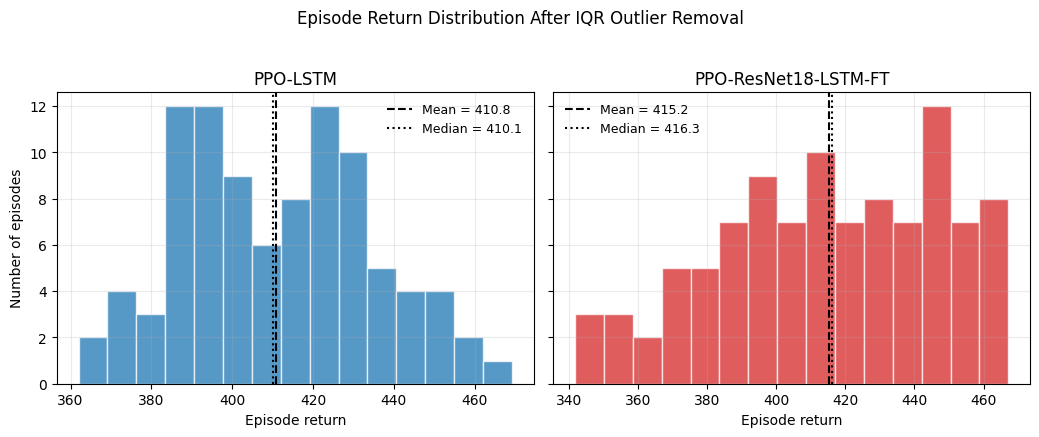

In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
eval_csv = PROJECT_ROOT / "results" / "final_5m_eval_per_episode.csv"
eval_episode_df = pd.read_csv(eval_csv)

METRIC = "episode_return"

model_order = ["PPO-LSTM", "PPO-ResNet18-LSTM-FT"]
titles = {
    "PPO-LSTM": "PPO-LSTM",
    "PPO-ResNet18-LSTM-FT": "PPO-ResNet18-LSTM-FT",
}
colors = {
    "PPO-LSTM": "#1f77b4",
    "PPO-ResNet18-LSTM-FT": "#d62728",
}


def remove_iqr_outliers(df, metric):
    q1 = df[metric].quantile(0.25)
    q3 = df[metric].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    clean = df[(df[metric] >= lower) & (df[metric] <= upper)].copy()
    removed = len(df) - len(clean)

    return clean, lower, upper, removed


clean_parts = []
outlier_report = []

for model in model_order:
    model_df = eval_episode_df[eval_episode_df["model"] == model].copy()
    clean_df, lower, upper, removed = remove_iqr_outliers(model_df, METRIC)

    clean_parts.append(clean_df)
    outlier_report.append(
        {
            "model": model,
            "original_n": len(model_df),
            "kept_n": len(clean_df),
            "removed_n": removed,
            "lower_bound": lower,
            "upper_bound": upper,
        }
    )

clean_eval_df = pd.concat(clean_parts, ignore_index=True)
outlier_report_df = pd.DataFrame(outlier_report)

display(outlier_report_df)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2), sharey=True)

for ax, model in zip(axes, model_order):
    data = clean_eval_df.loc[clean_eval_df["model"] == model, METRIC]

    ax.hist(
        data,
        bins=15,
        color=colors[model],
        alpha=0.75,
        edgecolor="white",
    )

    ax.axvline(
        data.mean(),
        color="black",
        linestyle="--",
        linewidth=1.5,
        label=f"Mean = {data.mean():.1f}",
    )
    ax.axvline(
        data.median(),
        color="black",
        linestyle=":",
        linewidth=1.5,
        label=f"Median = {data.median():.1f}",
    )

    ax.set_title(titles[model])
    ax.set_xlabel("Episode return")
    ax.grid(True, alpha=0.25)
    ax.legend(frameon=False, fontsize=9)

axes[0].set_ylabel("Number of episodes")
fig.suptitle("Episode Return Distribution After IQR Outlier Removal", y=1.03)

plt.tight_layout()

out_path = (
    PROJECT_ROOT
    / "results"
    / "figures"
    / "episode_return_distribution_iqr_filtered.pdf"
)
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_path, format="pdf", bbox_inches="tight")
print(f"Saved: {out_path}")

plt.show()

C:\Users\prajapaa\AppData\Local\Temp\ipykernel_152060\3901332882.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(
C:\Users\prajapaa\AppData\Local\Temp\ipykernel_152060\3901332882.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(
C:\Users\prajapaa\AppData\Local\Temp\ipykernel_152060\3901332882.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


Saved: c:\Users\prajapaa\OneDrive - The University of Colorado Denver\PHD\Courses\CSCI_5931_DL\project\DeepLearningWorldModelProject\results\figures\final_eval_boxplots.pdf


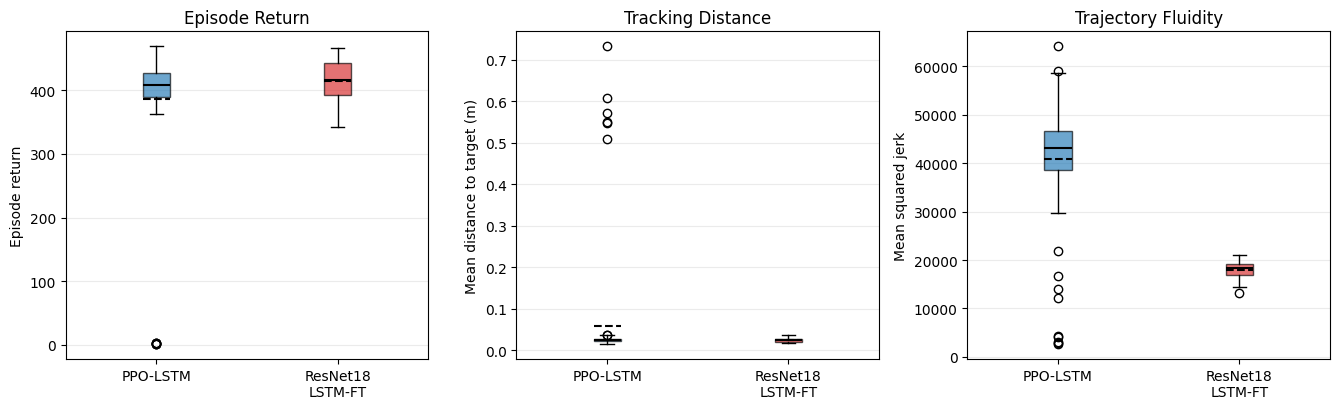

In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().parent
eval_csv = PROJECT_ROOT / "results" / "final_5m_eval_per_episode.csv"
eval_episode_df = pd.read_csv(eval_csv)

model_order = ["PPO-LSTM", "PPO-ResNet18-LSTM-FT"]
colors = ["#1f77b4", "#d62728"]

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))

metrics = [
    ("episode_return", "Episode Return", "Episode return"),
    ("tracking_distance", "Tracking Distance", "Mean distance to target (m)"),
    ("fluidity", "Trajectory Fluidity", "Mean squared jerk"),
]

for ax, (col, title, ylabel) in zip(axes, metrics):
    data = [
        eval_episode_df.loc[eval_episode_df["model"] == model, col].dropna()
        for model in model_order
    ]

    box = ax.boxplot(
        data,
        patch_artist=True,
        labels=["PPO-LSTM", "ResNet18\nLSTM-FT"],
        showmeans=True,
        meanline=True,
    )

    for patch, color in zip(box["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.65)

    for median in box["medians"]:
        median.set_color("black")
        median.set_linewidth(1.5)

    for mean in box["means"]:
        mean.set_color("black")
        mean.set_linewidth(1.5)
        mean.set_linestyle("--")

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(True, axis="y", alpha=0.25)

plt.tight_layout()

out_path = PROJECT_ROOT / "results" / "figures" / "final_eval_boxplots.pdf"
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_path, format="pdf", bbox_inches="tight")
print(f"Saved: {out_path}")

plt.show()